## Day 5 — EDA Part 2: Correlation & Data Storytelling 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### task1: Produce scatter plots and grouped box plots for the most important variable pairs in the dataset.

In [7]:
df = pd.read_csv('Students/StudentsPerformance.csv')
df.columns 

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

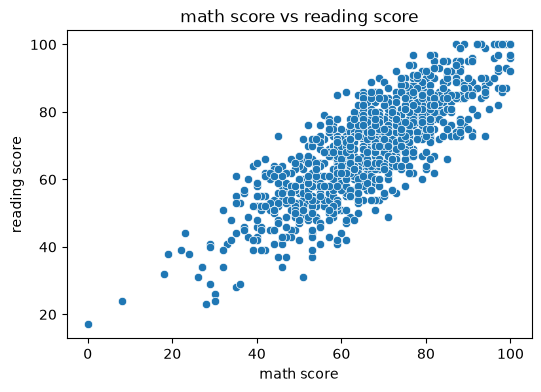

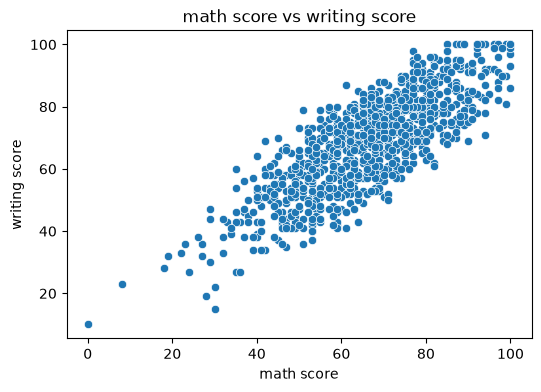

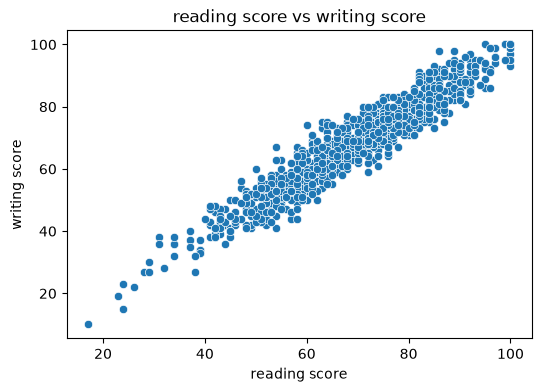

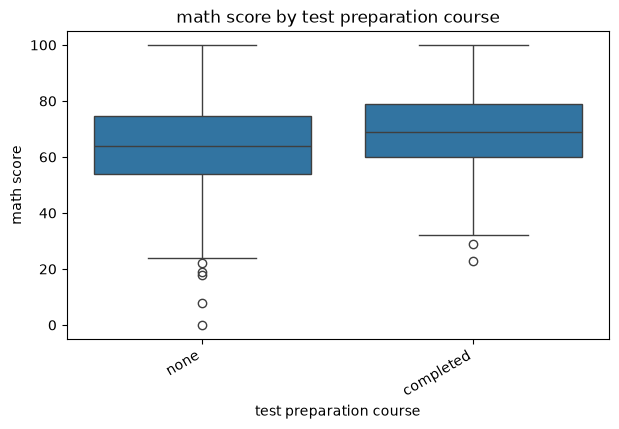

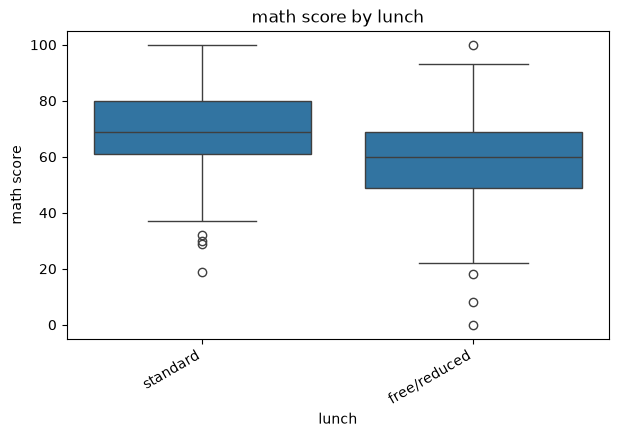

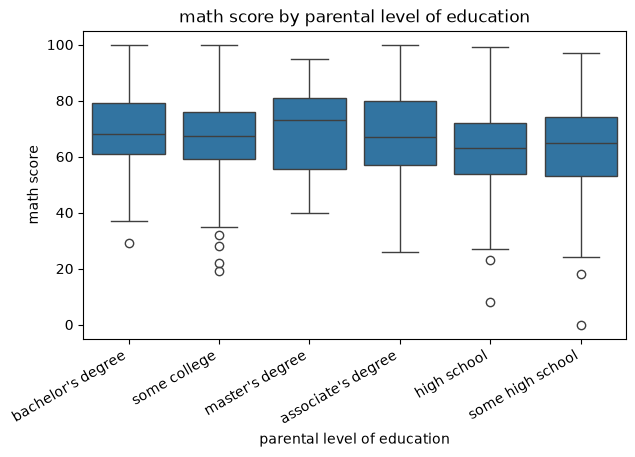

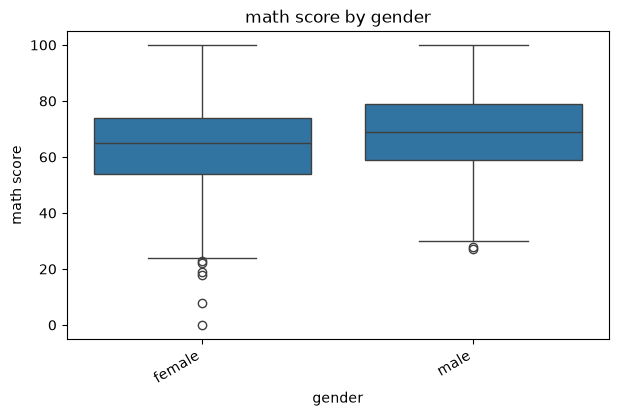

In [8]:
# --- Scatter plots: numeric vs numeric ---
numeric_pairs = [('math score', 'reading score'),
                  ('math score', 'writing score'),
                  ('reading score', 'writing score')]

for x, y in numeric_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

# --- Grouped box plots: categorical vs numeric (score) ---
categorical_vs_score = [
    ('test preparation course', 'math score'),
    ('lunch', 'math score'),
    ('parental level of education', 'math score'),
    ('gender', 'math score'),
]

for cat, num in categorical_vs_score:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=cat, y=num)
    plt.title(f"{num} by {cat}")
    plt.xticks(rotation=30, ha='right')
    plt.show()

### Bivariate Analysis Findings

**Scatter plots (score vs. score):**
All three pairs — math/reading, math/writing, reading/writing — show a 
**strong positive linear relationship**: students who score high on one 
subject tend to score high on the others, and low scorers cluster together 
too. Reading vs. writing shows the tightest, most linear relationship of 
the three; math vs. the other two is slightly more scattered, suggesting 
math performance is somewhat more independent of verbal skills.

**Grouped box plots (category vs. math score):**
- **Test preparation course:** students who *completed* the course have a 
  higher median math score (~69) than those who did *not* (~64), and a 
  narrower spread — completing prep appears to help and reduce variability.
- **Lunch:** students with *standard* lunch score noticeably higher 
  (median ~68) than those with *free/reduced* lunch (median ~60), likely 
  reflecting a socioeconomic effect on performance.
- **Parental level of education:** a mild upward trend — students whose 
  parents hold a *master's degree* have the highest median (~73), while 
  *high school* and *some high school* are lowest (~63-65). The effect is 
  real but smaller than lunch or test prep.
- **Gender:** male students have a slightly higher median math score 
  (~69) than female students (~65), though the spread is similar for both — 
  a modest, not dramatic, difference.

**Overall:** `test preparation course` and `lunch` appear to be the 
strongest categorical predictors of math score, while `gender` and 
`parental level of education` show smaller but still visible effects. All 
three numeric scores are highly correlated, suggesting a shared underlying 
"academic performance" factor rather than fully independent subject skills.

### task2: Compute the correlation matrix and visualize it as an annotated heatmap

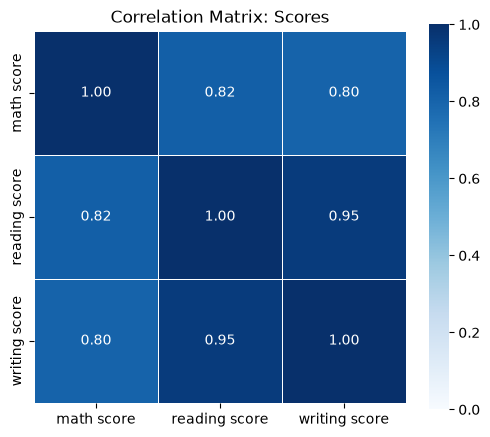

In [9]:
corr_matrix = df[['math score', 'reading score', 'writing score']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', 
            vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix: Scores")
plt.show()

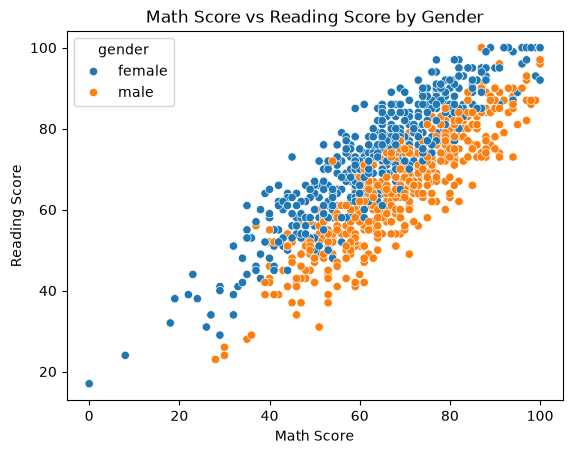

In [17]:
sns.scatterplot(data=df, x='math score', y='reading score', hue='gender')
plt.title("Math Score vs Reading Score by Gender")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

#### Scatter Plot: Math Score vs Reading Score by Gender

This scatter plot shows the relationship between **Math Score** and **Reading Score**, with points colored by **gender**.

##### Observations
- There is a **strong positive correlation** between Math and Reading scores. Students with higher Math scores generally achieve higher Reading scores.
- Female students (blue) tend to have **slightly higher Reading scores** than male students at similar Math score levels.
- Most students are clustered between **50–90** in both subjects.
- A few outliers with very low scores are visible, but they do not affect the overall positive trend.

### task3: Identify the two or three strongest relationships and state what they might mean for a future model.

### Strongest Relationships & Modeling Implications

1. **Reading ↔ Writing (r = 0.95)** — near-perfect correlation, likely 
   reflecting shared verbal ability rather than independent skills.
2. **Reading ↔ Math (r = 0.82)** and **Writing ↔ Math (r = 0.80)** — 
   strong, but weaker, suggesting math draws on a partly distinct skill set.

**Implication:** Reading and writing are largely redundant (0.95) — using 
both as separate model features risks multicollinearity; consider 
combining them (e.g. average) or using PCA. Math correlates more weakly 
with both, so it likely adds independent signal and is worth keeping as 
its own feature.

### task4:  Assemble the full EDA (statistics, univariate, outliers, bivariate, correlation) into one narrated notebook.

#### Load & Inspect the Data

In [10]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Missing Values & Outlier Detection

In [12]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

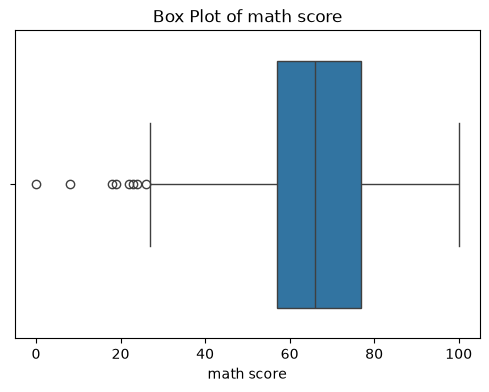

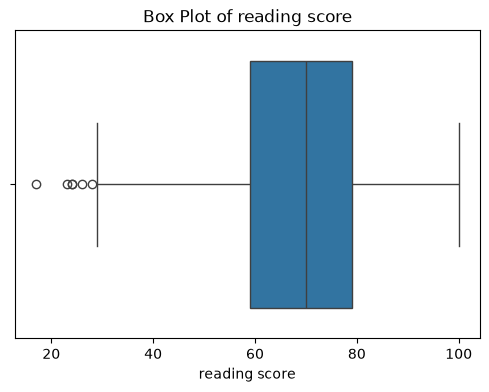

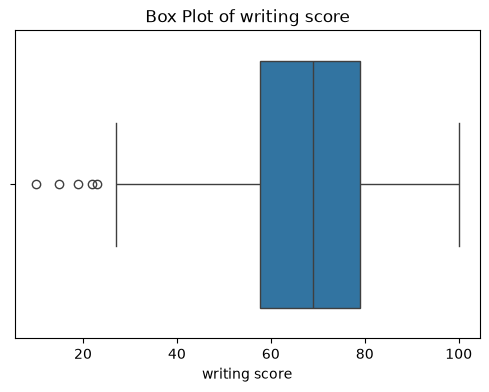

In [14]:
cols = ['math score', 'reading score', 'writing score']
for col in cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Box Plot of {col}")
    plt.show()

In [16]:
Q1_math = df['math score'].quantile(0.25)
Q3_math = df['math score'].quantile(0.75)
IQR_math = Q3_math - Q1_math
outliers = df[(df['math score'] < Q1_math - 1.5*IQR_math) | (df['math score'] > Q3_math + 1.5*IQR_math )]
print(f"Number of outliers in math score: {len(outliers)}")
print(outliers[['math score']])
Q1_reading = df['reading score'].quantile(0.25)
Q3_reading = df['reading score'].quantile(0.75)
IQR_reading = Q3_reading - Q1_reading
outliers_reading = df[(df['reading score'] < Q1_reading - 1.5*IQR_reading) | (df['reading score'] > Q3_reading + 1.5*IQR_reading)]
print(f"Number of outliers in reading score: {len(outliers_reading)}")
print(outliers_reading[['reading score']])
Q1_writing = df['writing score'].quantile(0.25)
Q3_writing = df['writing score'].quantile(0.75)
IQR_writing = Q3_writing - Q1_writing
outliers_writing = df[(df['writing score'] < Q1_writing - 1.5*IQR_writing) | (df['writing score'] > Q3_writing + 1.5*IQR_writing)]
print(f"Number of outliers in writing score: {len(outliers_writing)}")
print(outliers_writing[['writing score']])

Number of outliers in math score: 8
     math score
17           18
59            0
145          22
338          24
466          26
787          19
842          23
980           8
Number of outliers in reading score: 6
     reading score
59              17
76              26
211             28
327             23
596             24
980             24
Number of outliers in writing score: 5
     writing score
59              10
76              22
327             19
596             15
980             23


#### Univariate Analysis — Distributions

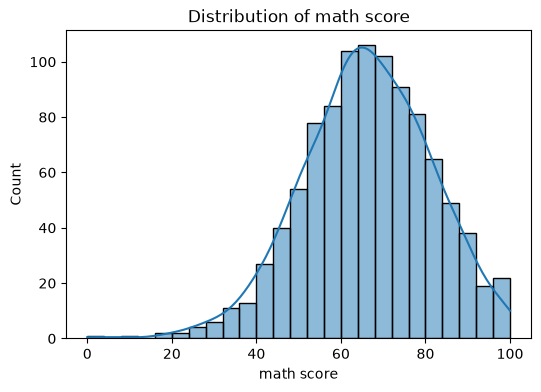

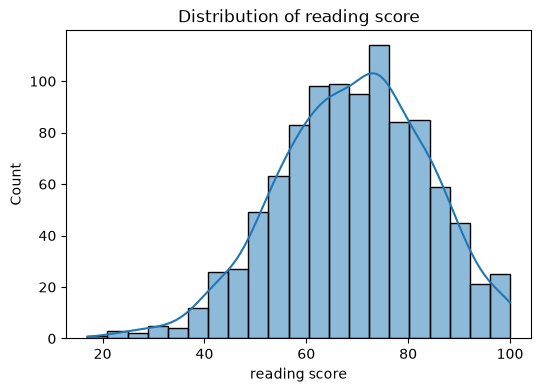

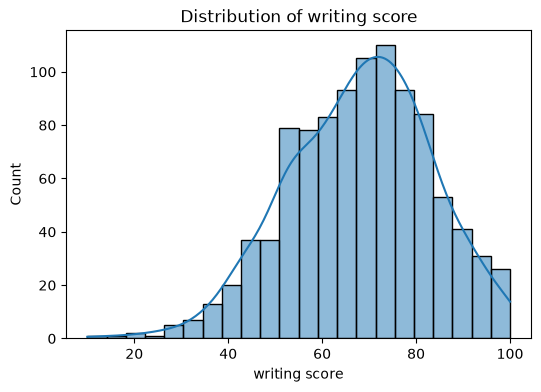

In [15]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#### Categorical Variables

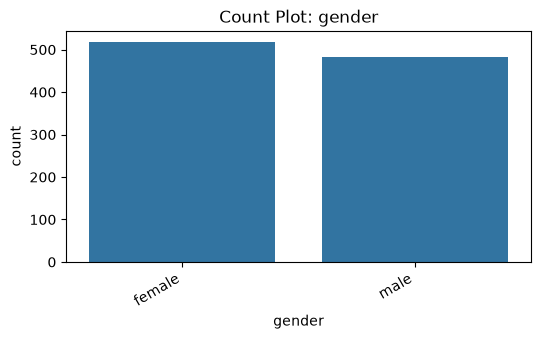

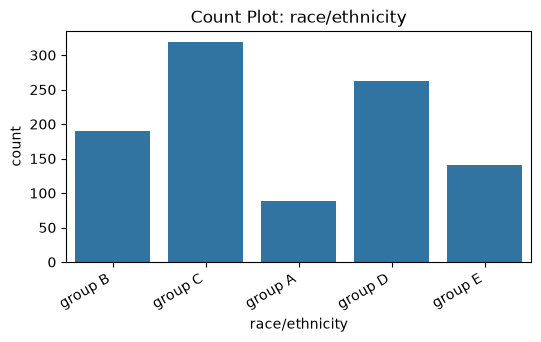

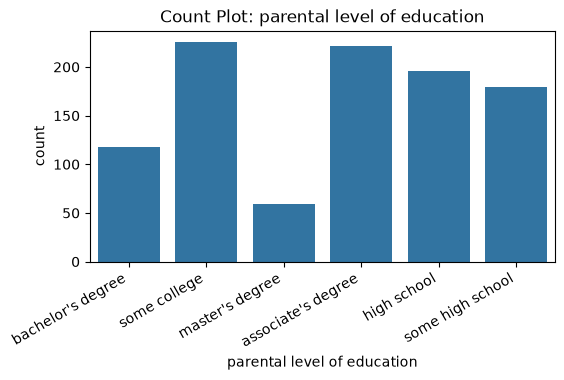

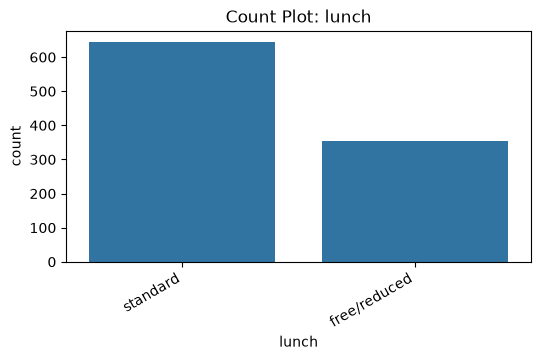

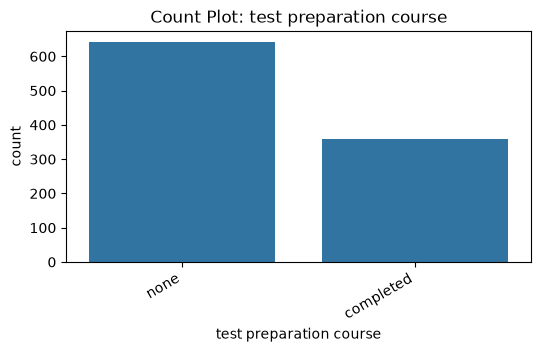

In [18]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education',
                     'lunch', 'test preparation course']

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot: {col}")
    plt.xticks(rotation=30, ha='right')
    plt.show()

#### Bivariate Analysis

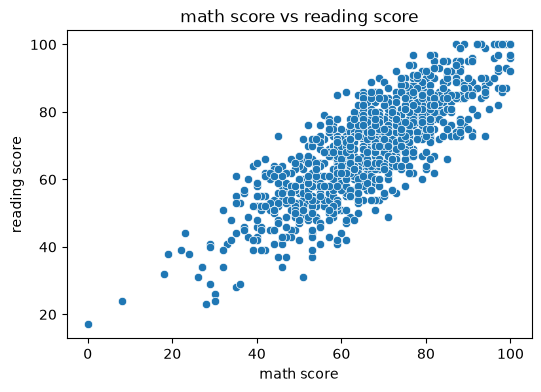

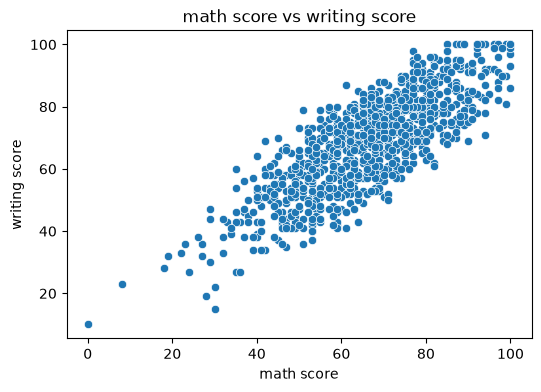

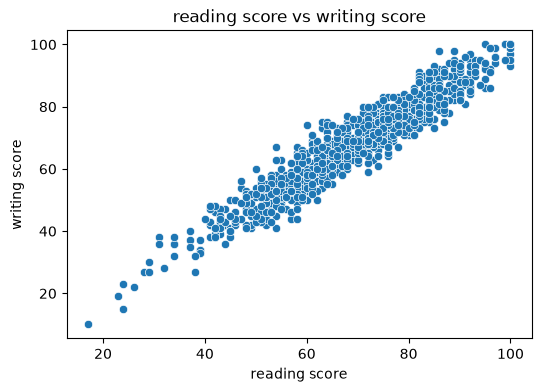

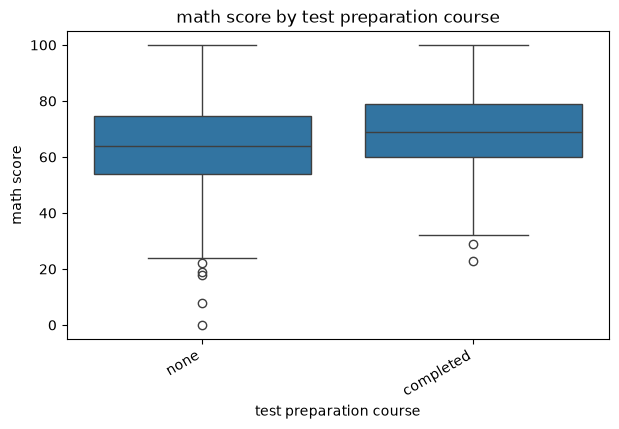

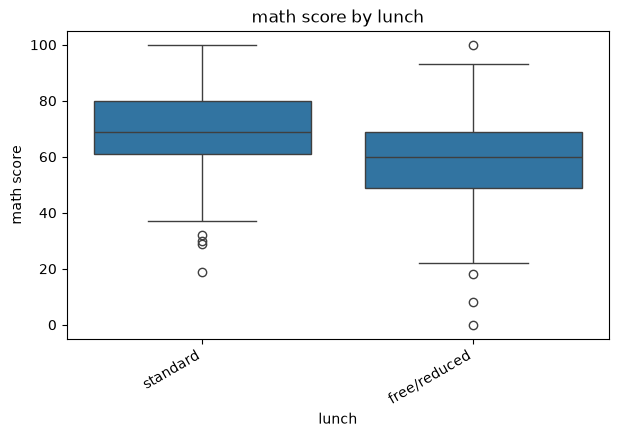

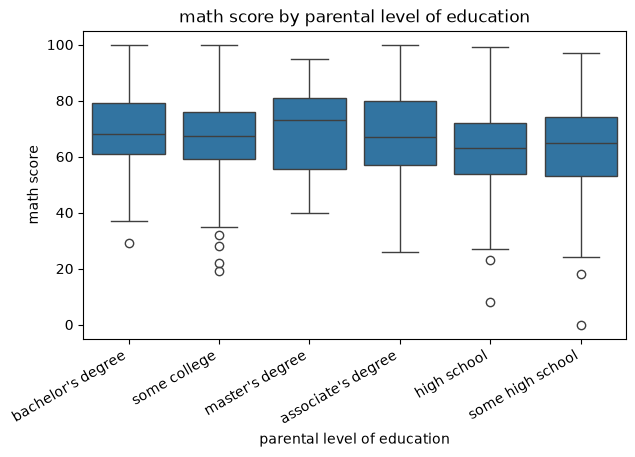

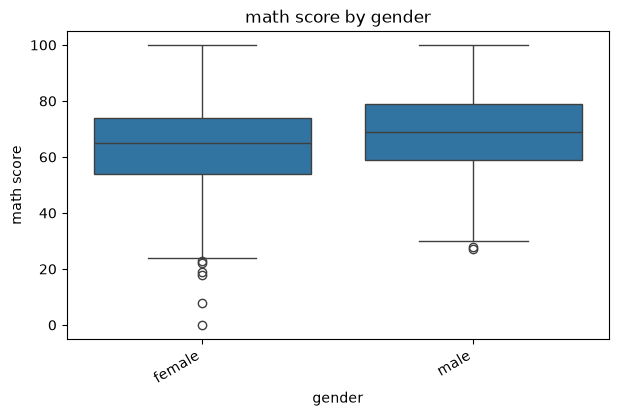

In [19]:
for x, y in [('math score', 'reading score'), 
             ('math score', 'writing score'),
             ('reading score', 'writing score')]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

for cat in ['test preparation course', 'lunch', 'parental level of education', 'gender']:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=cat, y='math score')
    plt.title(f"math score by {cat}")
    plt.xticks(rotation=30, ha='right')
    plt.show()

#### Correlation Matrix

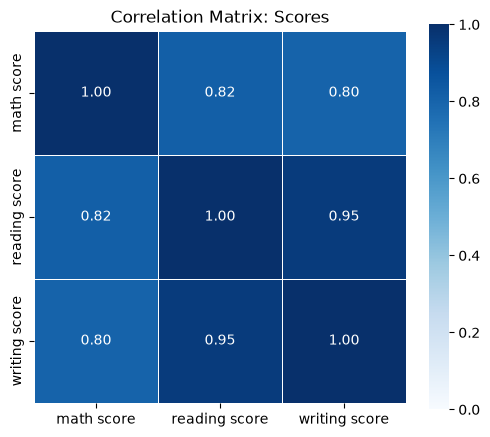

In [20]:
corr_matrix = df[['math score', 'reading score', 'writing score']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', 
            vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix: Scores")
plt.show()

## Summary of Key Findings

- Scores are left-skewed, with mean and median close together and a small 
  subgroup of low-performing students flagged by the IQR method as outliers.
- `test preparation course` and `lunch` show the strongest categorical 
  effects on math score; `gender` and `parental level of education` show 
  smaller effects.
- Reading and writing scores are highly correlated (r = 0.95), while math 
  correlates more moderately with both (r ≈ 0.80-0.82), suggesting math 
  captures a partly distinct skill.
- The dataset is clean, reasonably balanced, and ready for modeling in 
  Week 3.